# MoE-Sieve Companion Notebook

Reproduces the key analyses and figures from:
**MoE-Sieve: Routing-Guided LoRA for Efficient MoE Fine-Tuning**

All data is loaded from the tracked `outputs/` artifacts -- no re-training required.

Sections follow the paper structure:
- §3 Routing Profiling
- §5 Main Results
- §6 Ablations (random baseline)
- §7 Budget Dynamics and Variance


In [19]:
import glob
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

# ── paths ──────────────────────────────────────────────────────────────────
def find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "outputs").exists() and (candidate / "src").exists() and (candidate / "scripts").exists():
            return candidate
    raise RuntimeError("Could not locate repo root from the current working directory.")

ROOT = find_repo_root()
TEL  = ROOT / "outputs" / "telemetry"
OUT  = ROOT / "outputs"

SEEDS = [42, 99, 123, 456, 777, 789, 2026, 6969]

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})


In [20]:
# ── helpers ────────────────────────────────────────────────────────────────

def load_telemetry(model: str, dataset: str) -> dict:
    """Return routed MoE layers only as {layer_idx: {'counts': tensor, 'mass': tensor}}."""
    files = sorted((TEL / model / dataset).glob("telemetry_*_global.pt"))
    if not files:
        raise FileNotFoundError(f"No telemetry for {model}/{dataset}")
    raw = torch.load(files[0], map_location="cpu")

    routed = {}
    for k, v in raw.items():
        if not isinstance(k, int):
            continue
        counts = v["counts"].float()
        if counts.sum().item() == 0:
            continue  # skip dense / non-MoE placeholder layers, e.g. DeepSeek layer 0
        routed[k] = v

    if not routed:
        raise ValueError(f"Telemetry for {model}/{dataset} contains no routed MoE layers")
    return routed


def parse_spider_exec(summary_path: Path) -> float | None:
    ts_dir = summary_path.with_name(summary_path.stem.replace("_summary", "") + "_ts_inputs")
    out_file = ts_dir / "official_eval_output.txt"
    if not out_file.exists():
        return None
    for line in out_file.read_text().splitlines():
        if line.strip().startswith("execution"):
            parts = line.split()
            try:
                return float(parts[-1])
            except Exception:
                return None
    return None


def load_summaries(model: str, task: str, pattern: str = "*") -> pd.DataFrame:
    """Load matching *_summary.json files into a DataFrame.

    When `pattern` is an exact condition name such as `hotk16` or `full_lora`,
    filter by the parsed condition rather than substring matching. This avoids
    mistakes like `hotk4` also matching `hotk48`.
    """
    exact_match = pattern != "*" and not any(ch in pattern for ch in "*?[]")
    files = sorted((OUT / model / task).glob("*_summary.json"))
    rows = []
    for f in files:
        d = json.loads(f.read_text())
        if task == "spider":
            official = parse_spider_exec(f)
            if official is not None:
                d["acc"] = official
                d["metric"] = "official_test_suite_acc"
        name = f.stem.replace("_summary", "")
        m = re.search(r"_s(\d+)_(.+)$", name)
        if m:
            d["seed"] = int(m.group(1))
            d["condition"] = m.group(2)
        condition = d.get("condition")
        if exact_match:
            if condition != pattern:
                continue
        else:
            if pattern != "*" and pattern not in f.name:
                continue
        rows.append(d)
    return pd.DataFrame(rows)


def topk_experts(telem: dict, k: int, signal: str = "counts") -> dict:
    """Return {layer: set_of_top_k_expert_ids} ranked by counts or mass."""
    return {
        l: set(torch.topk(telem[l][signal].float(), k).indices.tolist())
        for l in telem
    }


def jaccard(a: set, b: set) -> float:
    return len(a & b) / len(a | b)


print(f"Helpers loaded. ROOT={ROOT}")


Helpers loaded. ROOT=/Users/andreamanzoni/Desktop/code/MoE_Sieve


---
## §3 — Routing Profiling: Quantifying Local Imbalance

### Table 2 — Routing imbalance stats (Global CV, Layer CV, Ratio, Cold%, Cov@25%)

In [21]:
MODEL_CFG = {
    "olmoe":    {"budget_k": 16, "n_routed": 64, "n_shared": 0, "active_routed": 8},
    "qwen":     {"budget_k": 15, "n_routed": 60, "n_shared": 4, "active_routed": 4},
    "deepseek": {"budget_k": 16, "n_routed": 64, "n_shared": 2, "active_routed": 6},
}

DATASETS_ALL = ["gsm8k", "spider", "hellaswag", "alpaca", "piqa",
                "arc_challenge", "boolq", "mbpp", "mmlu", "wikitext"]

def routing_stats(model: str) -> pd.DataFrame:
    cfg   = MODEL_CFG[model]
    k     = cfg["budget_k"]
    n     = cfg["n_routed"]
    uniform_share = 1.0 / n
    rows  = []
    for ds in DATASETS_ALL:
        try:
            telem = load_telemetry(model, ds)
        except FileNotFoundError:
            continue
        C = torch.stack([telem[l]["counts"].float() for l in sorted(telem)], dim=0)
        global_counts = C.sum(0)
        global_cv = (global_counts.std() / global_counts.mean()).item()
        layer_cv = (C.std(1) / C.mean(1)).mean().item()
        fracs = C / C.sum(1, keepdim=True)
        cold_frac = (fracs < 0.5 * uniform_share).float().mean().item()
        topk_mass = torch.topk(C, k, dim=1).values.sum(1) / C.sum(1)
        cov25 = topk_mass.mean().item()
        total_active = cfg["active_routed"] + cfg["n_shared"]
        token_cov25 = (cfg["n_shared"] + cov25 * cfg["active_routed"]) / total_active
        rows.append(dict(model=model, dataset=ds,
                         global_cv=global_cv, layer_cv=layer_cv,
                         ratio=layer_cv/global_cv,
                         cold_pct=cold_frac*100,
                         cov25=cov25*100,
                         token_cov25=token_cov25*100))
    return pd.DataFrame(rows)

dfs = pd.concat([routing_stats(m) for m in MODEL_CFG])

summary = (
    dfs.groupby("model")[["global_cv", "layer_cv", "ratio", "cold_pct", "cov25", "token_cov25"]]
       .mean()
       .round(3)
       .loc[["olmoe", "qwen", "deepseek"]]
)
summary.columns = ["Global CV", "Layer CV", "Ratio", "Cold %", "Cov@25%", "TokenCov@25%"]
summary.index = ["OLMoE-1B-7B", "Qwen1.5-MoE", "DeepSeek-MoE-16B"]
print(summary.to_string())


                  Global CV  Layer CV  Ratio  Cold %  Cov@25%  TokenCov@25%
OLMoE-1B-7B           0.218     0.876  3.989  28.486   53.049        53.049
Qwen1.5-MoE           0.077     0.377  4.886   5.208   37.407        68.704
DeepSeek-MoE-16B      0.104     0.535  5.152  11.354   42.504        56.878


### Figure — Global vs Per-Layer CV (reproduces fig_cv_comparison)

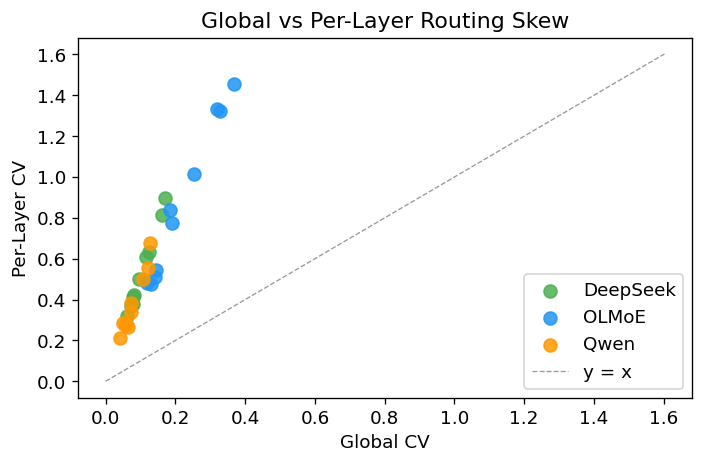

In [22]:
colors = {"olmoe": "#2196F3", "qwen": "#FF9800", "deepseek": "#4CAF50"}
labels = {"olmoe": "OLMoE", "qwen": "Qwen", "deepseek": "DeepSeek"}

fig, ax = plt.subplots(figsize=(6, 4))
for model, grp in dfs.groupby("model"):
    ax.scatter(grp["global_cv"], grp["layer_cv"],
               color=colors[model], label=labels[model], s=60, alpha=0.85)

# diagonal reference (y = x)
lim = max(dfs["global_cv"].max(), dfs["layer_cv"].max()) * 1.1
ax.plot([0, lim], [0, lim], "k--", lw=0.8, alpha=0.4, label="y = x")

ax.set_xlabel("Global CV")
ax.set_ylabel("Per-Layer CV")
ax.set_title("Global vs Per-Layer Routing Skew")
ax.legend()
fig.tight_layout()
plt.show()

### Figure — Coverage curves at top-k budget (reproduces fig_fixed_budget)

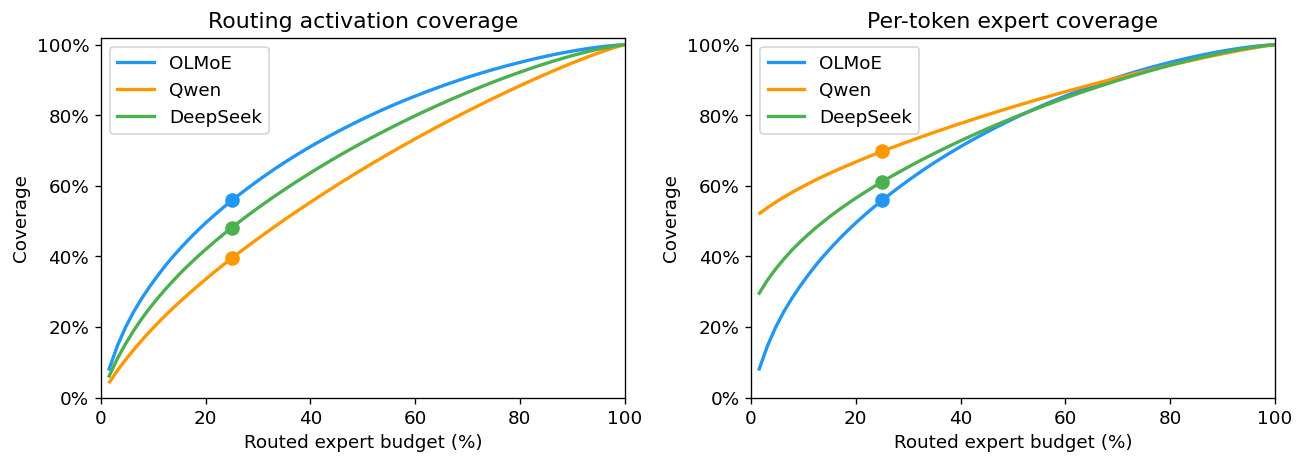

In [23]:
DATASETS_FT = ["gsm8k", "spider", "hellaswag"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for model, cfg in MODEL_CFG.items():
    n_routed = cfg["n_routed"]
    n_shared = cfg["n_shared"]
    active_routed = cfg["active_routed"]
    budget_k = cfg["budget_k"]
    ks = np.arange(1, n_routed + 1)
    cov_routed, cov_total = [], []
    for k in ks:
        r_vals, t_vals = [], []
        for ds in DATASETS_FT:
            try:
                telem = load_telemetry(model, ds)
            except FileNotFoundError:
                continue
            for l in telem:
                c = telem[l]["counts"].float()
                routed_cov = (torch.topk(c, k).values.sum() / c.sum()).item()
                r_vals.append(routed_cov)
                total_active = active_routed + n_shared
                token_cov = (n_shared + routed_cov * active_routed) / total_active
                t_vals.append(token_cov)
        cov_routed.append(np.mean(r_vals))
        cov_total.append(np.mean(t_vals))

    budget_pct = ks / n_routed * 100
    axes[0].plot(budget_pct, cov_routed, color=colors[model], label=labels[model], lw=2)
    axes[1].plot(budget_pct, cov_total,  color=colors[model], label=labels[model], lw=2)

    idx25 = budget_k - 1
    axes[0].scatter([25], [cov_routed[idx25]], color=colors[model], zorder=5, s=60)
    axes[1].scatter([25], [cov_total[idx25]], color=colors[model], zorder=5, s=60)

for ax, title in zip(axes, ["Routing activation coverage", "Per-token expert coverage"]):
    ax.set_xlabel("Routed expert budget (%)")
    ax.set_ylabel("Coverage")
    ax.set_title(title)
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 1.02)

fig.tight_layout()
plt.show()


### Figure — Cross-dataset Jaccard heatmap (all models, top-25% budget)

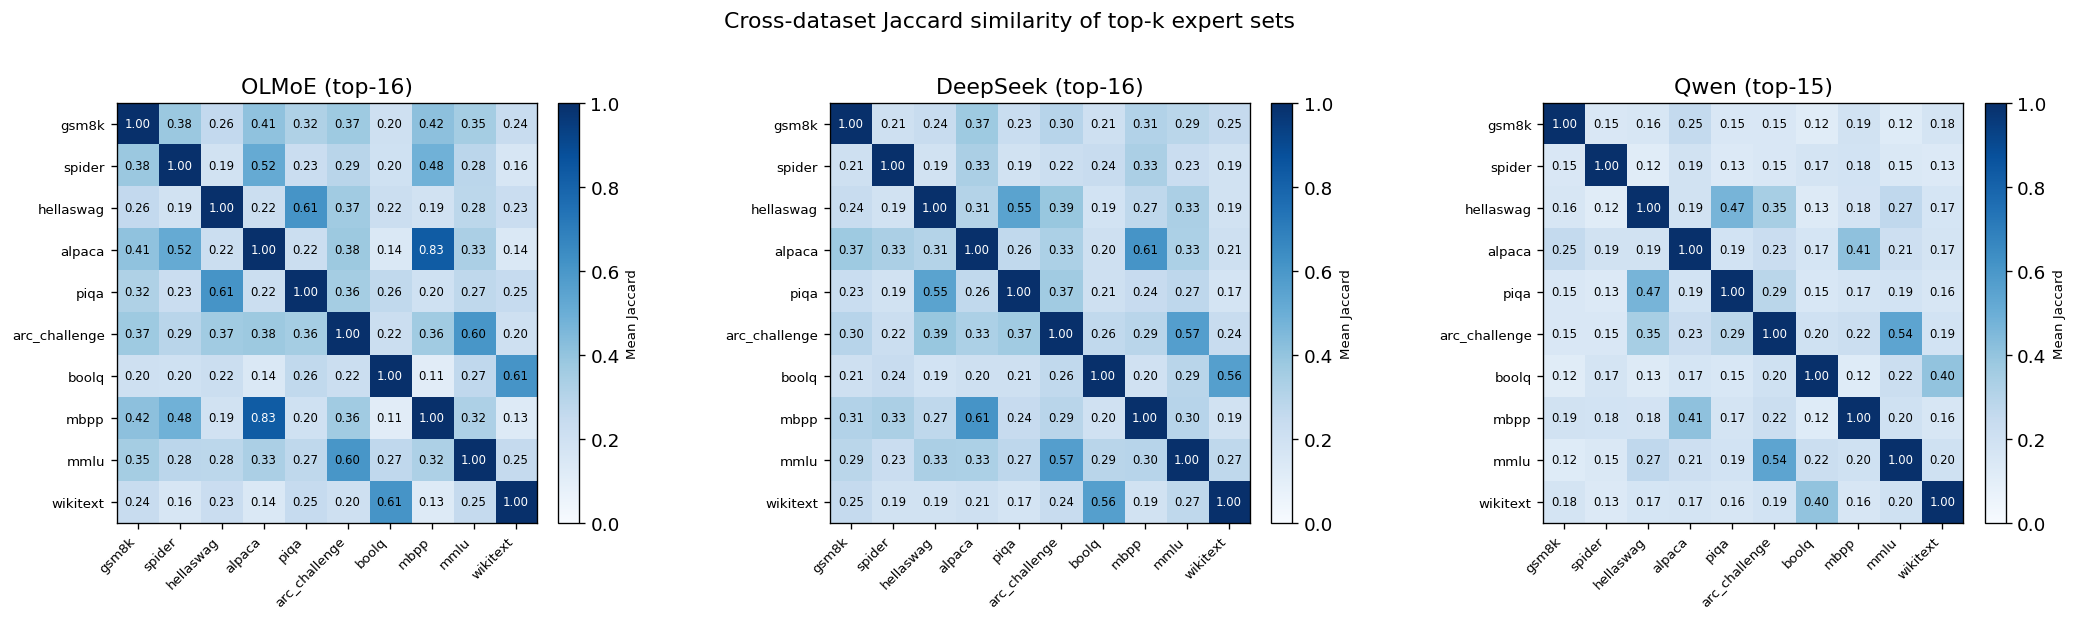

In [24]:
K_PER_MODEL = {m: cfg["budget_k"] for m, cfg in MODEL_CFG.items()}
ds_list = [d for d in DATASETS_ALL if all(sorted((TEL / m / d).glob("telemetry_*_global.pt")) for m in MODEL_CFG)]

jac_mats = {}
for model, k in K_PER_MODEL.items():
    topk_all = {}
    for ds in ds_list:
        telem = load_telemetry(model, ds)
        topk_all[ds] = topk_experts(telem, k)

    n = len(ds_list)
    J = np.zeros((n, n))
    for i, ds_i in enumerate(ds_list):
        for j, ds_j in enumerate(ds_list):
            vals = [jaccard(topk_all[ds_i][l], topk_all[ds_j][l]) for l in topk_all[ds_i]]
            J[i, j] = np.mean(vals)
    jac_mats[model] = J

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, model in zip(axes, ["olmoe", "deepseek", "qwen"]):
    J = jac_mats[model]
    im = ax.imshow(J, vmin=0, vmax=1, cmap="Blues")
    ax.set_xticks(range(len(ds_list)))
    ax.set_xticklabels(ds_list, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(ds_list)))
    ax.set_yticklabels(ds_list, fontsize=8)
    ax.set_title(f"{labels[model]} (top-{K_PER_MODEL[model]})")
    for i in range(len(ds_list)):
        for j in range(len(ds_list)):
            val = J[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if val > 0.65 else "black")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Mean Jaccard", fontsize=8)

fig.suptitle("Cross-dataset Jaccard similarity of top-k expert sets", y=1.02)
fig.tight_layout()
plt.show()

---
## §5 — Main Results: Hot-25% vs Full LoRA

### Table 3 — Mean accuracy, paired delta, 95% CI

In [25]:
MODELS_FT = {"olmoe": "hotk16", "qwen": "hotk15"}
TASKS     = ["spider", "gsm8k", "hellaswag"]

rows = []
for model, hot_cond in MODELS_FT.items():
    for task in TASKS:
        full = load_summaries(model, task, "full_lora")
        hot  = load_summaries(model, task, hot_cond)
        if full.empty or hot.empty:
            continue
        # align on seed
        merged = full.merge(hot, on="seed", suffixes=("_full", "_hot"))
        diffs  = merged["acc_hot"] - merged["acc_full"]
        ci     = stats.t.interval(0.95, df=len(diffs)-1,
                                   loc=diffs.mean(), scale=stats.sem(diffs))
        rows.append({
            "Model": model.upper(), "Task": task,
            "Full LoRA":  f"{merged['acc_full'].mean():.3f} ± {merged['acc_full'].std():.3f}",
            "Hot 25%":    f"{merged['acc_hot'].mean():.3f} ± {merged['acc_hot'].std():.3f}",
            "Δ (pp)":     f"{diffs.mean()*100:+.2f}",
            "95% CI":     f"[{ci[0]*100:+.2f}, {ci[1]*100:+.2f}]",
            "Eqv@2pp":    "✓" if abs(ci[0]*100) < 2 and abs(ci[1]*100) < 2 else "×",
        })

table3 = pd.DataFrame(rows)
print(table3.to_string(index=False))

Model      Task     Full LoRA       Hot 25% Δ (pp)         95% CI Eqv@2pp
OLMOE    spider 0.396 ± 0.028 0.399 ± 0.016  +0.30 [-2.04, +2.64]       ×
OLMOE     gsm8k 0.304 ± 0.011 0.304 ± 0.006  -0.08 [-1.45, +1.30]       ✓
OLMOE hellaswag 0.805 ± 0.005 0.807 ± 0.008  +0.17 [-0.71, +1.05]       ✓
 QWEN    spider 0.520 ± 0.015 0.511 ± 0.005  -0.93 [-1.88, +0.03]       ✓
 QWEN     gsm8k 0.590 ± 0.012 0.592 ± 0.007  +0.20 [-0.77, +1.17]       ✓
 QWEN hellaswag 0.885 ± 0.002 0.892 ± 0.001  +0.73 [+0.53, +0.93]       ✓


### Table 4 — Efficiency: trainable parameters, checkpoint size, wall-clock time

In [26]:
# Hardcoded from paper (timing measured on a single GPU, GSM8K, 3 epochs, 351 steps)
efficiency = pd.DataFrame([
    {"Model": "OLMoE-1B-7B",
     "Params Full":  "311.5 M", "Params Hot": "85.0 M",  "Param Red.": "72.7%",
     "Ckpt Full":    "1.25 GB", "Ckpt Hot":   "340 MB",  "Ckpt Red.":  "73.4%",
     "Time Full":    "1h 48m",  "Time Hot":   "54 min",  "Speedup":    "~50%"},
    {"Model": "Qwen1.5-MoE",
     "Params Full":  "509.7 M", "Params Hot": "151.3 M", "Param Red.": "70.3%",
     "Ckpt Full":    "2.04 GB", "Ckpt Hot":   "606 MB",  "Ckpt Red.":  "71.0%",
     "Time Full":    "3h 23m",  "Time Hot":   "1h 44m",  "Speedup":    "~49%"},
])
print(efficiency.to_string(index=False))


      Model Params Full Params Hot Param Red. Ckpt Full Ckpt Hot Ckpt Red. Time Full Time Hot Speedup
OLMoE-1B-7B     311.5 M     85.0 M      72.7%   1.25 GB   340 MB     73.4%    1h 48m   54 min    ~50%
Qwen1.5-MoE     509.7 M    151.3 M      70.3%   2.04 GB   606 MB     71.0%    3h 23m   1h 44m    ~49%


---
## §6 — Ablations

### Random baseline — Hot-k vs Random-k at matched budget (OLMoE × GSM8K)

In [27]:
for k in [8, 16]:
    hot  = load_summaries("olmoe", "gsm8k", f"hotk{k}")
    rand = load_summaries("olmoe", "gsm8k", f"randk{k}")
    if hot.empty or rand.empty:
        print(f"k={k}: missing data"); continue
    print(f"k={k}:  hot  {hot['acc'].mean():.3f} ± {hot['acc'].std():.3f}  "
          f"random {rand['acc'].mean():.3f} ± {rand['acc'].std():.3f}  "
          f"Δ={( hot['acc'].mean() - rand['acc'].mean())*100:+.1f} pp")

k=8:  hot  0.291 ± 0.008  random 0.270 ± 0.012  Δ=+2.1 pp
k=16:  hot  0.304 ± 0.006  random 0.279 ± 0.009  Δ=+2.5 pp


### Table 5 — Greedy (budget-25) vs. uniform hot-25% (from `budgetp25_bcount` condition)

In [28]:
greedy_cond = {"olmoe": "budgetp25_bcount", "qwen": "budgetp25_bcount"}
rows = []
for model, hot_cond in MODELS_FT.items():
    for task in TASKS:
        unif = load_summaries(model, task, hot_cond)
        grd  = load_summaries(model, task, greedy_cond[model])
        if unif.empty or grd.empty:
            continue
        rows.append({
            "Model":    model.upper(),
            "Task":     task,
            "Uniform":  f"{unif['acc'].mean():.3f} ± {unif['acc'].std():.3f}",
            "Greedy":   f"{grd['acc'].mean():.3f} ± {grd['acc'].std():.3f}",
            "Δ (pp)":   f"{(grd['acc'].mean() - unif['acc'].mean())*100:+.2f}",
        })
print(pd.DataFrame(rows).to_string(index=False))


Model      Task       Uniform        Greedy Δ (pp)
OLMOE    spider 0.399 ± 0.016 0.405 ± 0.019  +0.62
OLMOE     gsm8k 0.304 ± 0.006 0.304 ± 0.008  +0.02
OLMOE hellaswag 0.807 ± 0.008 0.806 ± 0.008  -0.06
 QWEN    spider 0.511 ± 0.005 0.509 ± 0.012  -0.19
 QWEN     gsm8k 0.592 ± 0.007 0.591 ± 0.010  -0.14
 QWEN hellaswag 0.892 ± 0.001 0.895 ± 0.001  +0.21


---
## §7 — Budget Dynamics and Stability

### Figures — OLMoE budget curves across GSM8K, Spider, and HellaSwag (paper-style plots)

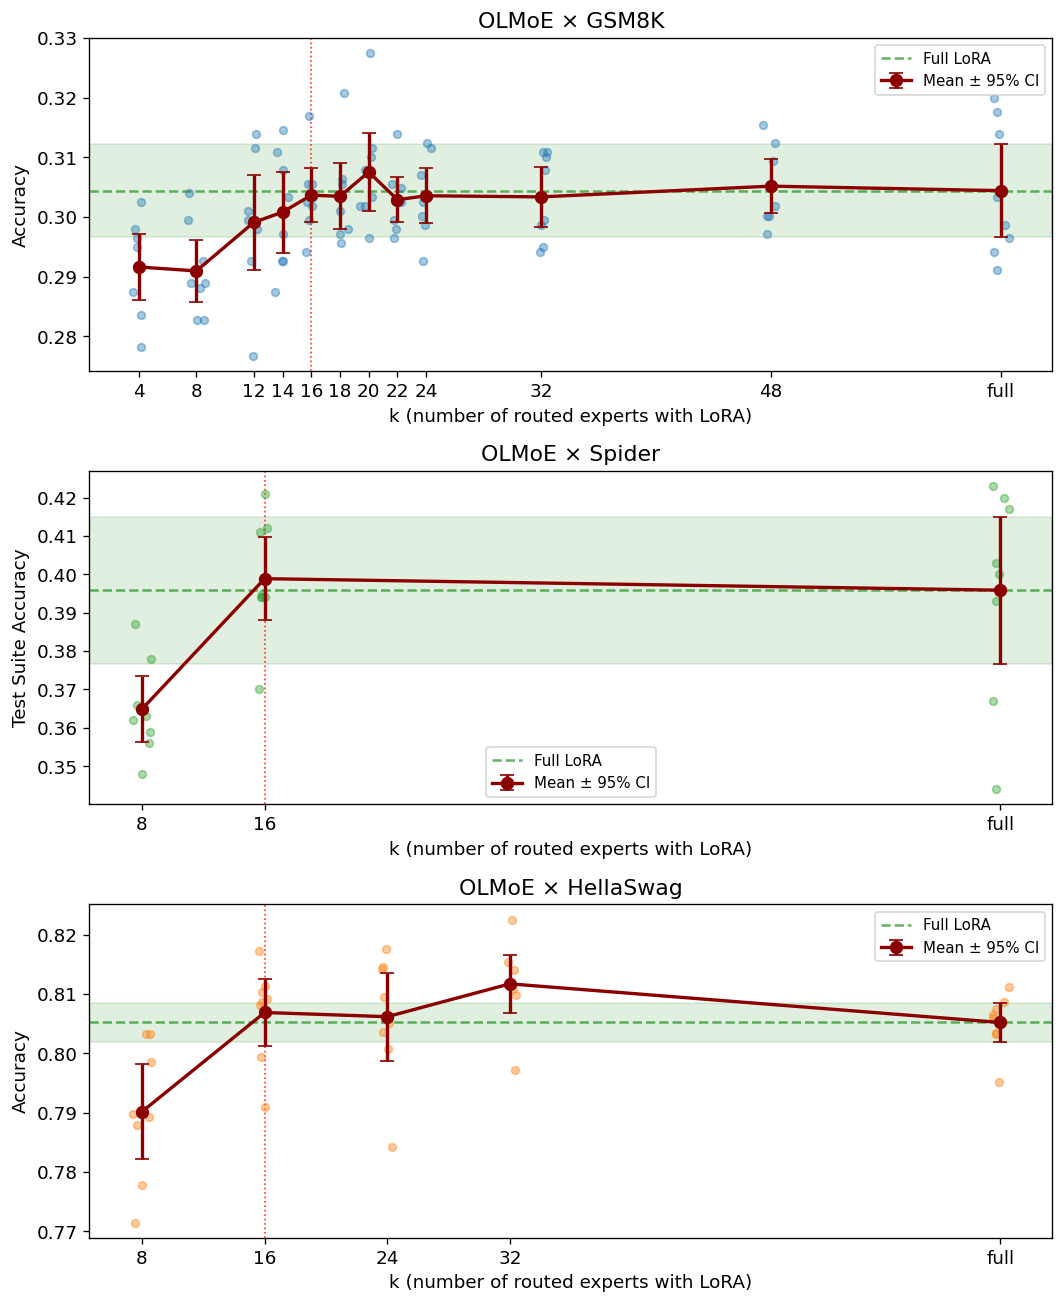

In [29]:
TASK_SPECS = {
    "gsm8k": {
        "k_values": [4, 8, 12, 14, 16, 18, 20, 22, 24, 32, 48, 64],
        "color": "#1f77b4",
        "ylabel": "Accuracy",
        "title": "OLMoE × GSM8K",
    },
    "spider": {
        "k_values": [8, 16, 64],
        "color": "#2ca02c",
        "ylabel": "Test Suite Accuracy",
        "title": "OLMoE × Spider",
    },
    "hellaswag": {
        "k_values": [8, 16, 24, 32, 64],
        "color": "#ff7f0e",
        "ylabel": "Accuracy",
        "title": "OLMoE × HellaSwag",
    },
}

fig, axes = plt.subplots(3, 1, figsize=(9, 11))

for ax, (task, spec) in zip(axes, TASK_SPECS.items()):
    rows = []
    for k in spec["k_values"]:
        if k == 64:
            df = load_summaries("olmoe", task, "full_lora")
        else:
            df = load_summaries("olmoe", task, f"hotk{k}")
        if df.empty:
            continue
        accs = df["acc"].astype(float).values
        rows.append({
            "k": k,
            "accs": accs,
            "mean": accs.mean(),
            "se": stats.sem(accs) if len(accs) > 1 else 0.0,
        })

    if not rows:
        ax.set_visible(False)
        continue

    rows = sorted(rows, key=lambda r: r["k"])
    k_vals = [r["k"] for r in rows]

    for r in rows:
        k = r["k"]
        accs = r["accs"]
        jit = np.random.RandomState(int(k)).normal(0, 0.25, len(accs))
        ax.scatter([k + j for j in jit], accs, alpha=0.4, s=22, color=spec["color"], zorder=3)

    means = [r["mean"] for r in rows]
    yerr = [1.96 * r["se"] for r in rows]
    ax.errorbar(k_vals, means, yerr=yerr,
                fmt='o-', color='darkred', lw=2, ms=7, capsize=4, zorder=5,
                label='Mean ± 95% CI')

    full_row = next((r for r in rows if r["k"] == 64), None)
    if full_row is not None:
        fm = full_row["mean"]
        fse = full_row["se"]
        ax.axhspan(fm - 1.96 * fse, fm + 1.96 * fse, alpha=0.12, color='green')
        ax.axhline(fm, color='green', ls='--', alpha=0.6, label='Full LoRA')

    if 16 in k_vals:
        ax.axvline(16, color='red', linestyle=':', lw=1, alpha=0.8)

    ax.set_xticks(k_vals)
    ax.set_xticklabels(['full' if k == 64 else str(int(k)) for k in k_vals])
    ax.set_xlabel('k (number of routed experts with LoRA)')
    ax.set_ylabel(spec["ylabel"])
    ax.set_title(spec["title"])
    ax.legend(fontsize=9, loc='best')

fig.tight_layout()
plt.show()


### Table — Seed-to-seed standard deviation (Table 5 in paper)

In [30]:
rows = []
for model, hot_cond in MODELS_FT.items():
    for task in TASKS:
        full = load_summaries(model, task, "full_lora")
        hot  = load_summaries(model, task, hot_cond)
        if full.empty or hot.empty: continue
        std_full = full["acc"].std()
        std_hot  = hot["acc"].std()
        rows.append({
            "Model": model.upper(), "Task": task,
            "Full std": f"{std_full:.3f}",
            "Hot std":  f"{std_hot:.3f}",
            "Ratio":    f"{std_hot/std_full:.2f}×",
        })

print(pd.DataFrame(rows).to_string(index=False))

Model      Task Full std Hot std Ratio
OLMOE    spider    0.028   0.016 0.57×
OLMOE     gsm8k    0.011   0.006 0.58×
OLMOE hellaswag    0.005   0.008 1.68×
 QWEN    spider    0.015   0.005 0.36×
 QWEN     gsm8k    0.012   0.007 0.59×
 QWEN hellaswag    0.002   0.001 0.67×


---
## Appendix A.1 — Per-Layer Expert Utilization

### Table 7 — Per-layer profiling: OLMoE × Spider

In [31]:
model = "olmoe"
ds    = "spider"
cfg   = MODEL_CFG[model]
k     = cfg["budget_k"]
n     = cfg["n_routed"]
uniform_share = 1.0 / n

telem  = load_telemetry(model, ds)
layers = sorted(telem.keys())

rows = []
for l in layers:
    c    = telem[l]["counts"].float()
    cv   = (c.std() / c.mean()).item()
    cold = (c < 0.5 * uniform_share * c.sum()).float().mean().item()
    topk_cov = (torch.topk(c, k).values.sum() / c.sum()).item()
    p = c / c.sum()
    p = p[p > 0]
    entropy = -(p * p.log()).sum().item()
    norm_ent = entropy / (n * 0 + torch.tensor(n).float().log()).item()
    rows.append({"Layer": l, "CV": round(cv,2), "Cold%": f"{cold*100:.0f}%",
                 f"Top-{k} Cov%": f"{topk_cov*100:.0f}%", "Norm. Entropy": round(norm_ent,3)})

print(pd.DataFrame(rows).to_string(index=False))


 Layer   CV Cold% Top-16 Cov%  Norm. Entropy
     0 0.82   25%         53%          0.935
     1 0.86   23%         52%          0.938
     2 1.09   41%         59%          0.902
     3 1.10   47%         64%          0.886
     4 1.39   55%         71%          0.845
     5 1.47   47%         70%          0.837
     6 1.43   50%         72%          0.828
     7 1.55   50%         73%          0.815
     8 1.51   58%         73%          0.819
     9 1.44   53%         71%          0.836
    10 1.31   50%         68%          0.857
    11 1.64   55%         75%          0.809
    12 1.42   58%         72%          0.838
    13 1.41   56%         72%          0.835
    14 1.38   55%         72%          0.841
    15 1.54   59%         74%          0.818


---
## Appendix A.2 — Per-Layer Activation Heatmaps (Figure 5)

Row-normalised activation counts for OLMoE across all 10 profiling datasets.
Each row = layer, each column = expert. Code/programming tasks show sharper hot-head patterns.

/var/folders/3w/0wb2jxmn4pl06ty63d941f0m0000gn/T/ipykernel_92856/3773409229.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


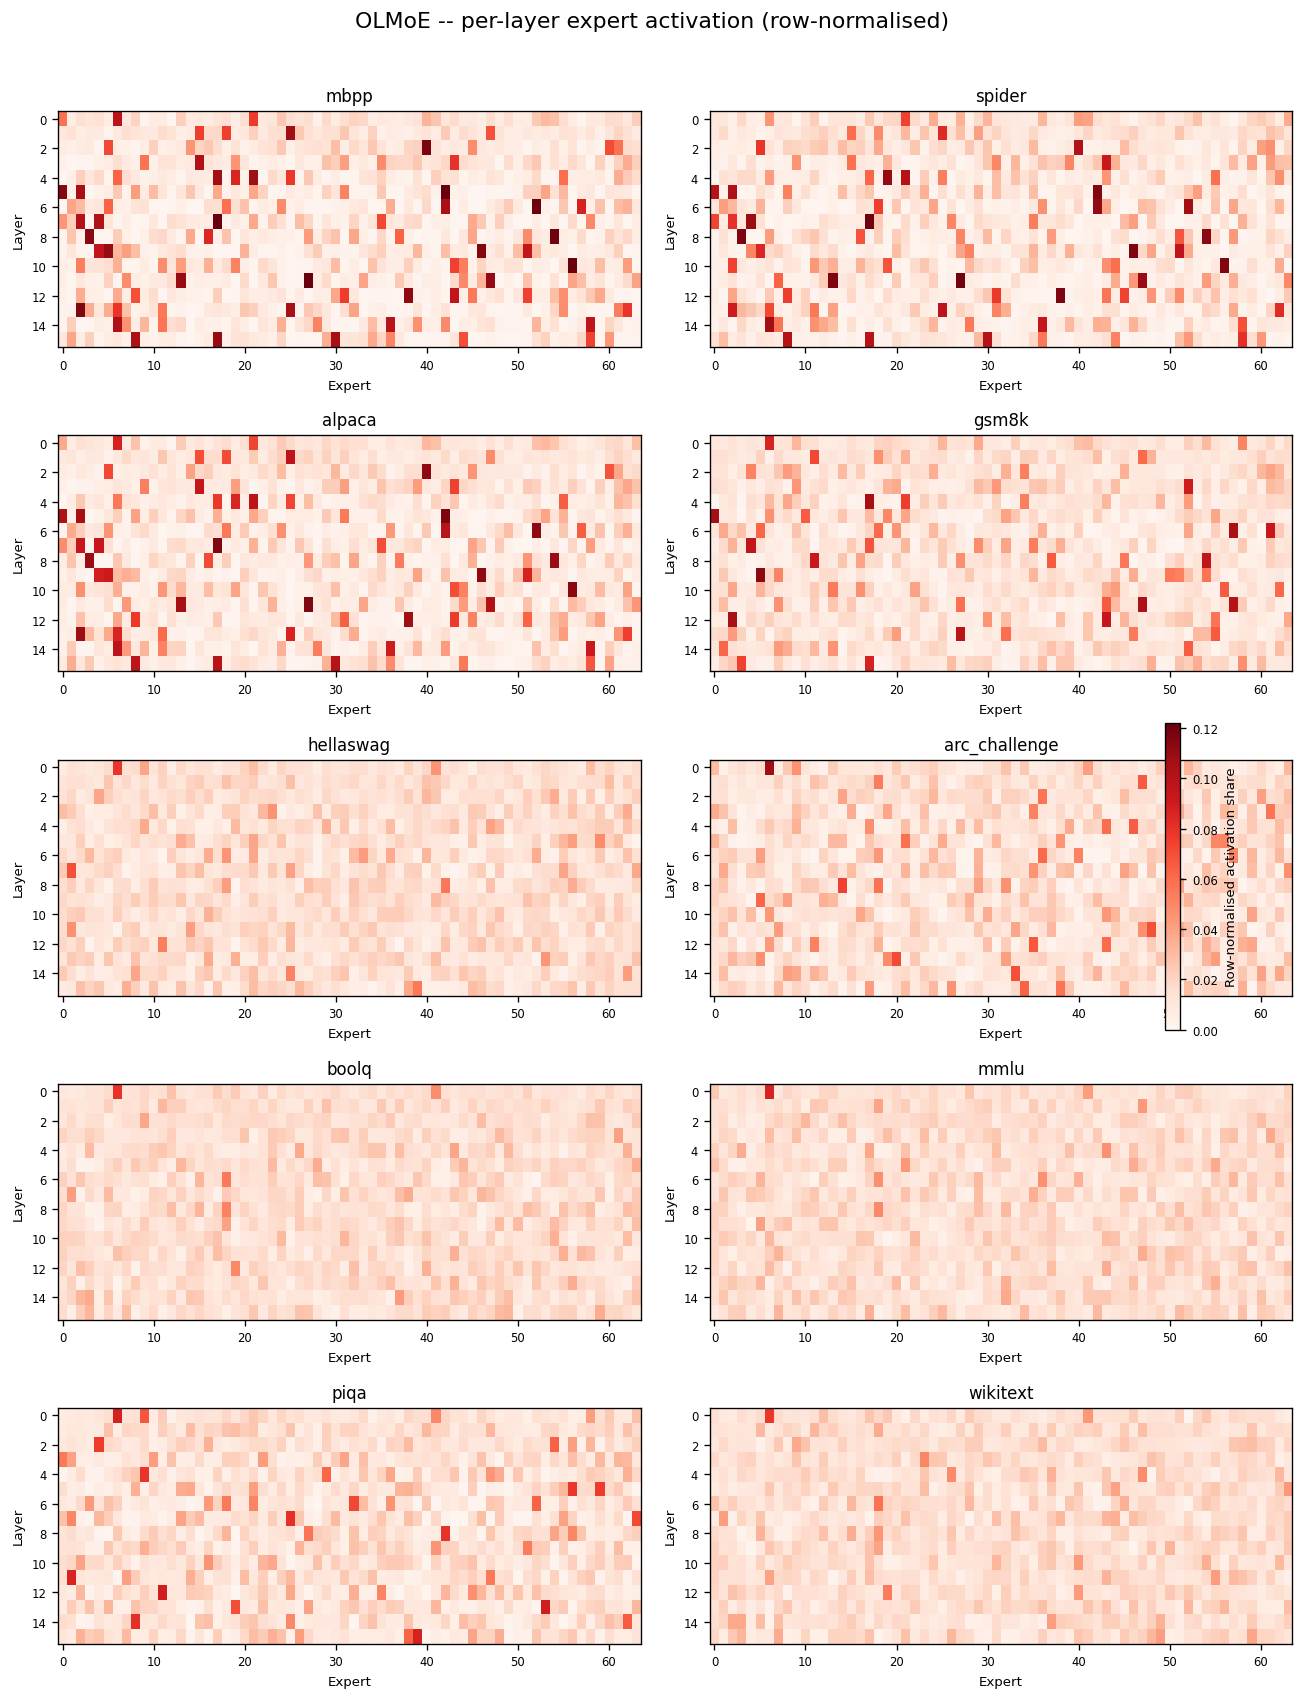

In [32]:
datasets_ordered = ["mbpp", "spider", "alpaca", "gsm8k",
                    "hellaswag", "arc_challenge", "boolq", "mmlu", "piqa", "wikitext"]

available = []
heatmaps = {}
vmax = 0.0
for ds in datasets_ordered:
    try:
        telem = load_telemetry("olmoe", ds)
    except FileNotFoundError:
        continue
    layers = sorted(telem.keys())
    C = torch.stack([telem[l]["counts"].float() for l in layers], dim=0)
    C_norm = C / C.sum(1, keepdim=True)
    arr = C_norm.numpy()
    heatmaps[ds] = arr
    vmax = max(vmax, float(arr.max()))
    available.append(ds)

n_ds = len(available)
ncols = 2
nrows = (n_ds + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(11, nrows * 2.8))
axes = np.atleast_1d(axes).flatten()

im = None
for ax, ds in zip(axes, available):
    im = ax.imshow(heatmaps[ds], aspect="auto", cmap="Reds", vmin=0, vmax=vmax)
    ax.set_title(ds, fontsize=10)
    ax.set_xlabel("Expert", fontsize=8)
    ax.set_ylabel("Layer", fontsize=8)
    ax.tick_params(labelsize=7)

for ax in axes[len(available):]:
    ax.set_visible(False)

if im is not None:
    cbar = fig.colorbar(im, ax=axes[:len(available)].tolist(), fraction=0.015, pad=0.02)
    cbar.set_label("Row-normalised activation share", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

fig.suptitle("OLMoE -- per-layer expert activation (row-normalised)", y=1.01)
fig.tight_layout()
plt.show()


---
## Appendix A.3 — Profiling Stability (Figure 6)

Jaccard similarity of top-k expert sets when profiling on only 10% of data (50 Multinomial bootstrap trials per dataset).
Approximates subsampling from aggregated count data via Multinomial resampling.

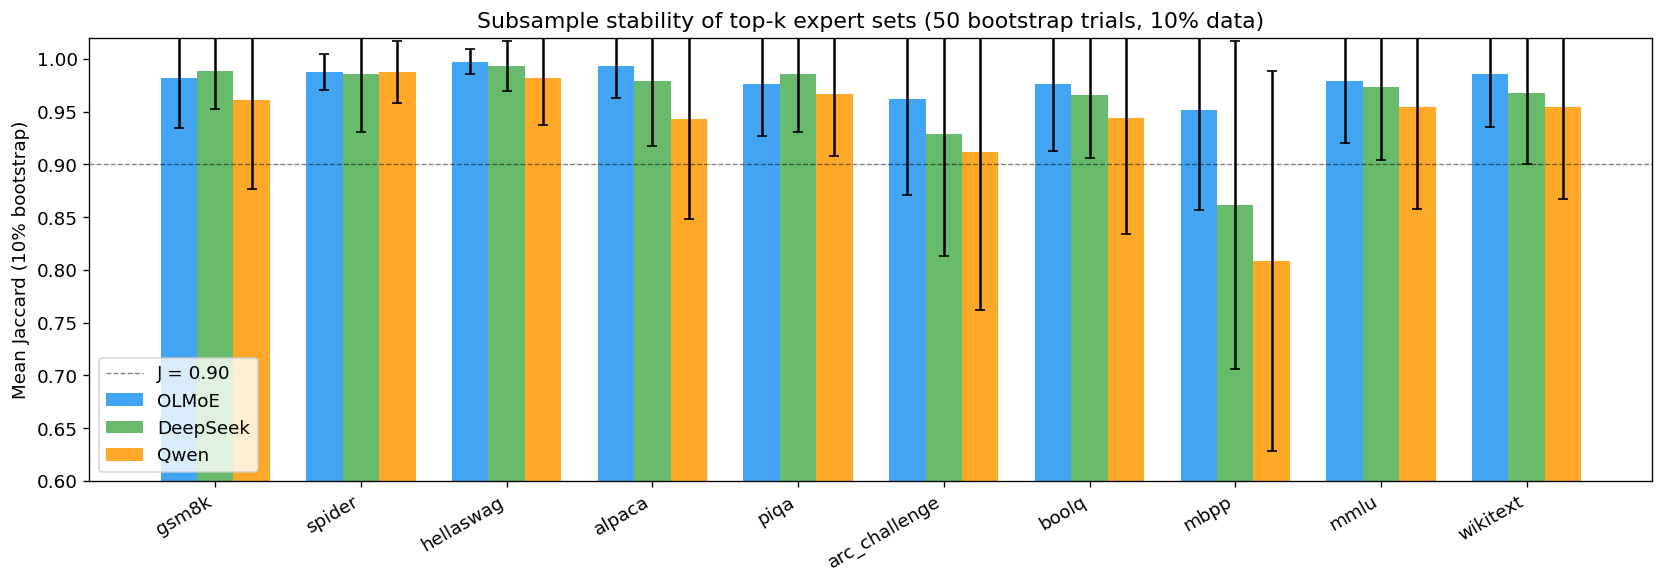

In [33]:
N_BOOT   = 50
SUBSAMP  = 0.10
rng      = np.random.default_rng(0)

bar_data = {}  # model -> {ds -> (mean_J, min_J)}

for model, cfg in MODEL_CFG.items():
    k = cfg["budget_k"]
    bar_data[model] = {}
    for ds in DATASETS_ALL:
        try:
            telem = load_telemetry(model, ds)
        except FileNotFoundError:
            continue
        layers = sorted(telem.keys())
        full_topk = topk_experts(telem, k)

        per_layer_means = []
        per_layer_mins  = []
        for l in layers:
            c = telem[l]["counts"].float().numpy()
            total = int(c.sum())
            sub_n = max(1, int(total * SUBSAMP))
            probs = c / c.sum()
            jacs  = []
            for _ in range(N_BOOT):
                sample = rng.multinomial(sub_n, probs).astype(float)
                topk_idx = set(np.argsort(sample)[-k:].tolist())
                jacs.append(jaccard(full_topk[l], topk_idx))
            per_layer_means.append(np.mean(jacs))
            per_layer_mins.append(np.min(jacs))
        bar_data[model][ds] = (np.mean(per_layer_means), np.mean(per_layer_mins))

ds_common = [d for d in DATASETS_ALL if all(d in bar_data[m] for m in MODEL_CFG)]
x = np.arange(len(ds_common))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
for i, model in enumerate(["olmoe", "deepseek", "qwen"]):
    means = [bar_data[model][d][0] for d in ds_common]
    mins  = [bar_data[model][d][1] for d in ds_common]
    errs  = [m - mn for m, mn in zip(means, mins)]
    ax.bar(x + i*width, means, width, label=labels[model],
           color=colors[model], alpha=0.85, yerr=errs, capsize=3)

ax.axhline(0.9, color="black", ls="--", lw=0.8, alpha=0.5, label="J = 0.90")
ax.set_xticks(x + width)
ax.set_xticklabels(ds_common, rotation=30, ha="right")
ax.set_ylabel("Mean Jaccard (10% bootstrap)")
ax.set_ylim(0.6, 1.02)
ax.set_title("Subsample stability of top-k expert sets (50 bootstrap trials, 10% data)")
ax.legend()
fig.tight_layout()
plt.show()


---
## Appendix B — Statistical Tests (Table 8)

TOST equivalence p-values and paired t-test for hot-25% vs. full LoRA.

In [34]:
from scipy.stats import ttest_rel

def tost_pvalue(diffs, margin):
    """One-sided p-values for upper and lower tests; return max (conservative)."""
    se = stats.sem(diffs)
    t_upper = (np.mean(diffs) - margin) / se
    t_lower = (np.mean(diffs) + margin) / se
    p_upper = stats.t.cdf(t_upper, df=len(diffs)-1)
    p_lower = 1 - stats.t.cdf(t_lower, df=len(diffs)-1)
    return max(p_upper, p_lower)

def fmt_p(p):
    return "<.001" if p < 0.001 else f"{p:.3f}"

rows = []
for model, hot_cond in MODELS_FT.items():
    for task in TASKS:
        full = load_summaries(model, task, "full_lora")
        hot  = load_summaries(model, task, hot_cond)
        if full.empty or hot.empty: continue
        merged = full.merge(hot, on="seed", suffixes=("_full", "_hot"))
        diffs  = (merged["acc_hot"] - merged["acc_full"]).values
        t_p    = ttest_rel(merged["acc_hot"], merged["acc_full"]).pvalue
        rows.append({
            "Model":    model.upper(), "Task": task,
            "Δ (pp)":  f"{diffs.mean()*100:+.2f}",
            "ε=1pp":   fmt_p(tost_pvalue(diffs, 0.01)) + (" ✓" if tost_pvalue(diffs, 0.01) < 0.05 else ""),
            "ε=2pp":   fmt_p(tost_pvalue(diffs, 0.02)) + (" ✓" if tost_pvalue(diffs, 0.02) < 0.05 else ""),
            "ε=3pp":   fmt_p(tost_pvalue(diffs, 0.03)) + (" ✓" if tost_pvalue(diffs, 0.03) < 0.05 else ""),
            "t-test p": fmt_p(t_p),
        })

print(pd.DataFrame(rows).to_string(index=False))

Model      Task Δ (pp)   ε=1pp   ε=2pp   ε=3pp t-test p
OLMOE    spider  +0.30   0.251   0.065 0.015 ✓    0.771
OLMOE     gsm8k  -0.08   0.078 0.006 ✓ <.001 ✓    0.900
OLMOE hellaswag  +0.17 0.030 ✓ <.001 ✓ <.001 ✓    0.665
 QWEN    spider  -0.93   0.429 0.016 ✓ <.001 ✓    0.055
 QWEN     gsm8k  +0.20 0.046 ✓ 0.002 ✓ <.001 ✓    0.643
 QWEN hellaswag  +0.73 0.007 ✓ <.001 ✓ <.001 ✓    <.001


---
## Appendix C — Per-Layer Greedy Budget Allocation (Table 9)

Uniform k=16 vs. greedy (budgetp25_bcount) per-layer allocation for OLMoE × GSM8K.

In [35]:
model, task = "olmoe", "gsm8k"
k_uniform = MODEL_CFG[model]["budget_k"]
telem = load_telemetry(model, task)
layers = sorted(telem.keys())

rows = []
for l in layers:
    c = telem[l]["counts"].float()
    unif_cov = (torch.topk(c, k_uniform).values.sum() / c.sum()).item() * 100
    rows.append({"Layer": int(l), "Uniform k": k_uniform, "Uniform Cov%": round(unif_cov, 1)})

df_greedy = pd.DataFrame(rows)
# Greedy k values from paper (Table 9)
greedy_ks = [15, 14, 16, 19, 16, 15, 17, 17, 15, 12, 15, 12, 15, 16, 20, 22]
df_greedy["Greedy k"] = greedy_ks[:len(df_greedy)]
df_greedy["Greedy Cov%"] = [
    round((torch.topk(telem[l]["counts"].float(), gk).values.sum() / telem[l]["counts"].float().sum()).item() * 100, 1)
    for l, gk in zip(layers, greedy_ks[:len(layers)])
]

mean_row = {col: round(df_greedy[col].mean(), 1) for col in ["Uniform k", "Uniform Cov%", "Greedy k", "Greedy Cov%"]}
mean_row["Layer"] = "Mean"

df_display = df_greedy.copy()
df_display["Layer"] = df_display["Layer"].astype(int).astype(str)
df_display = pd.concat([df_display, pd.DataFrame([mean_row])], ignore_index=True)
for col in ["Uniform k", "Greedy k"]:
    df_display[col] = df_display[col].apply(lambda x: int(x) if pd.notna(x) and float(x).is_integer() else x)

print(df_display.to_string(index=False))


Layer  Uniform k  Uniform Cov%  Greedy k  Greedy Cov%
    0         16          48.5        15         46.8
    1         16          48.0        14         44.5
    2         16          52.8        16         52.8
    3         16          52.4        19         57.8
    4         16          57.5        16         57.5
    5         16          58.7        15         56.9
    6         16          66.6        17         68.4
    7         16          58.2        17         60.0
    8         16          60.5        15         58.8
    9         16          58.8        12         51.9
   10         16          55.4        15         53.6
   11         16          62.5        12         55.7
   12         16          60.3        15         58.6
   13         16          59.5        16         59.5
   14         16          51.0        20         58.3
   15         16          56.1        22         67.7
 Mean         16          56.7        16         56.8


---
## Appendix D — Supplementary Budget Sweeps (Table 10)

OLMoE budget sweeps for HellaSwag and Spider (8 seeds each).

In [36]:
supp_specs = {
    "hellaswag": {"k_values": [8, 16, 24, 32], "label": "OLMoE × HellaSwag"},
    "spider":    {"k_values": [8, 16],          "label": "OLMoE × Spider"},
}

for task, spec in supp_specs.items():
    rows = []
    for k in spec["k_values"]:
        df = load_summaries("olmoe", task, f"hotk{k}")
        if not df.empty:
            rows.append({"Setting": f"hot k={k}", "Accuracy": f"{df['acc'].mean():.3f} ± {df['acc'].std():.3f}"})
    # budget-25 condition
    bp = load_summaries("olmoe", task, "budgetp25_bcount")
    if not bp.empty:
        rows.append({"Setting": "budget-25",  "Accuracy": f"{bp['acc'].mean():.3f} ± {bp['acc'].std():.3f}"})
    fl = load_summaries("olmoe", task, "full_lora")
    if not fl.empty:
        rows.append({"Setting": "full LoRA",  "Accuracy": f"{fl['acc'].mean():.3f} ± {fl['acc'].std():.3f}"})
    print(f"\n{spec['label']}")
    print(pd.DataFrame(rows).to_string(index=False))



OLMoE × HellaSwag
  Setting      Accuracy
  hot k=8 0.790 ± 0.011
 hot k=16 0.807 ± 0.008
 hot k=24 0.806 ± 0.011
 hot k=32 0.812 ± 0.007
budget-25 0.806 ± 0.008
full LoRA 0.805 ± 0.005

OLMoE × Spider
  Setting      Accuracy
  hot k=8 0.365 ± 0.012
 hot k=16 0.399 ± 0.016
budget-25 0.405 ± 0.019
full LoRA 0.396 ± 0.028
